
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Edición 2025**

---
## Trabajo práctico entregable - Parte 1

In [25]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas as pd
import seaborn

seaborn.set_context('talk')

## Lectura del dataset

En la notebook 00 se explican los detalles de la siguiente sección.

In [26]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2025_processed.csv'
df = pd.read_csv(url)
df.to_csv("programming_language_raw.csv", index=False)


In [27]:
df[:10]

,Unnamed: 0,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,...,salir_o_seguir_contestando_sobre_las_guardias,work_on_call_duty,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,profile_age,profile_gender,habias_respondido_nuestra_encuesta_en_ediciones_anteriores,sueldo_dolarizado,seniority,_sal
0,0,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),6500000.00,5800000.00,Cobro parte del salario en dólares,NaN,De uno a tres sueldos,Performance de la compañía,...,NaN,NaN,NaN,NaN,45,Hombre Cis,Sí,True,Senior,6500000.00
1,1,Ciudad Autónoma de Buenos Aires,Full-Time,Contractor,12700000.00,10200000.00,Cobro todo el salario en dólares,NaN,Un sueldo,Performance de la compañía,...,Terminar encuesta,No,0.0,Bruto,32,Mujer Cis,Sí,True,Senior,12700000.00
2,2,Córdoba,Full-Time,Staff (planta permanente),3952805.00,3137662.00,Cobro parte del salario en dólares,985,No,No recibo bono,...,NaN,NaN,NaN,NaN,29,Hombre Cis,Sí,True,Semi-Senior,3952805.00
3,3,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),1606000.00,1360000.00,Cobro parte del salario en dólares,1004,No,No recibo bono,...,NaN,NaN,NaN,NaN,25,Hombre Cis,Sí,True,Semi-Senior,1606000.00
4,4,Córdoba,Full-Time,Tercerizado (trabajo a través de consultora o ...,1325301.00,NaN,Cobro parte del salario en dólares,NaN,No,No recibo bono,...,Terminar encuesta,NaN,NaN,NaN,22,Hombre Cis,Sí,True,Senior,1325301.00
5,5,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),2670205.00,2167989.00,Cobro parte del salario en dólares,986,No,No recibo bono,...,Terminar encuesta,No,0.0,Porcentaje de mi sueldo bruto,48,Hombre Cis,Sí,True,Senior,2670205.00
6,6,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),4000000.00,4000000.00,Cobro todo el salario en dólares,NaN,No,No recibo bono,...,Terminar encuesta,No,0.0,Bruto,50,Hombre Cis,Sí,True,Senior,4000000.00
7,7,Córdoba,Full-Time,Staff (planta permanente),4200000.00,3600000.00,Cobro parte del salario en dólares,1070,No,No recibo bono,...,Responder sobre guardias,"Sí, pasiva",0.0,Porcentaje de mi sueldo bruto,43,Hombre Cis,Sí,True,Senior,4200000.00
8,8,Buenos Aires,Full-Time,Freelance,3000000.00,2000000.00,Mi sueldo está dolarizado (pero cobro en moned...,1150,No,No recibo bono,...,NaN,NaN,NaN,NaN,41,Hombre Cis,No,True,Senior,3000000.00
9,9,Buenos Aires,Full-Time,Staff (planta permanente),3953142.06,3258576.49,Mi sueldo está dolarizado (pero cobro en moned...,NaN,Un sueldo,Performance de la compañía,...,NaN,NaN,NaN,NaN,47,Hombre Cis,Sí,True,Senior,3953142.06


# Ejercicio 1 - Análisis descriptivo

Responder a la pregunta: **¿Cuáles son los lenguajes de programación asociados a los mejores salarios?**

Para ello:
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en una sub-población. Por ejemplo, se pueden limitar a personas con un salario mayor que 100000 pesos, o a las personas que trabajan sólo en "Data Science", pero deben justificar su elección y reformular la pregunta inicial de ser necesario.
  * Obtener una lista de los lenguajes de programación más populares. Decidir cuántos y cuáles seleccionan para incluir en el análisis.
  * Para cada una de las otras columnas del punto anterior, elegir los rangos o valores seleccionan para incluir en el análisis.
3. Seleccionar métricas que ayuden a responder la pregunta, y los métodos para analizarlas. Elegir UNA de las siguientes opciones:
  * Comparar las distribuciones de salario para cada lenguaje utilizando visualizaciones. Como la visualización es el producto final, debe ser clara y mostrar información relevante.
  * Comparar medidas de estadística descriptiva sobre la distribución de salario para cada lenguaje. Sean creativos, la estadística descriptiva nos permite decir cosas como: "el 10% de los mejores sueldos los ganan, en su mayoría, programadores que saben kotlin!" (donde *mayoría* es un término medio engañoso que sólo significa más del 50%). Para comparar múltiples lenguajes, les recomendamos usar también visualizaciones.
  * Comparar probabilidades. Por ejemplo: "Si sabés Python o Java, tenés un 30% más de chances de ganar arriba de 1000K".

Si lo consideran necesario, realicen varias iteraciones. Es decir, si encuentran que las distribuciones de los lenguajes de programación que seleccionaron inicialmente no son muy diferentes, pueden re-hacer el análisis usando sólo los lenguajes de programación que son diferentes.

In [28]:
# complete here if you want to include more columns
# relevant_columns = ['tools_programming_languages','salary_monthly_BRUTO', 'salary_monthly_NETO', 'profile_years_experience']
relevant_columns = ['salary_monthly_BRUTO', 'salary_monthly_NETO', 'profile_years_experience', 'work_province', 'profile_gender']

### Conteo de frecuencias de los lenguajes de programación

La columna que contiene información sobre los lenguajes de programación utilizados es `tools_programming_languages`. Sus valores son strings con los lenguajes seleccionados separados por comas.



In [29]:
df.tools_programming_languages[:3]

0                       Ninguno de los anteriores
1    CSS, HTML, Java, Javascript, SQL, TypeScript
2                                             SQL
Name: tools_programming_languages, dtype: object

Las siguientes celdas de código separan estos lenguajes de programación y cuentan la frecuencia con la que aparecen.

No es necesario entender este código en profundidad, aunque sí es un buen ejercicio.

In [30]:
# Convert the comma-separated string of languages to a list of string.
# Remove 'ninguno de los anteriores' option, spaces and training commas.
def split_languages(languages_str):
  if not isinstance(languages_str, str):
    return []
  # Remove 'other' option
  languages_str = languages_str.lower()\
    .replace('ninguno de los anteriores', '')
  # Split string into list of items
  # Remove spaces and commas for each item
  return [lang.strip().replace(',', '')
          for lang in languages_str.split()]

# Create a new column with the list of languages
df.loc[:, 'cured_programming_languages'] = df.tools_programming_languages\
    .apply(split_languages)
if 'cured_programming_languages' not in relevant_columns:
    relevant_columns.append('cured_programming_languages')

# Duplicate each row of df for each programming language
# mentioned in the response.
# We only include in df_lang the columns we are going to analyze later, so we
# don't duplicate innecesary information.
df_lang = df.cured_programming_languages\
    .apply(pd.Series).stack()\
    .reset_index(level=-1, drop=True).to_frame()\
    .join(df[relevant_columns])\
    .rename(columns={0: 'programming_language'})
# Horrible programming style! But a lot of data science code can be written with
# as concatenations of functions (pipelines), and there's no elegant way of
# doing that on Python.
df_lang[:5]

,programming_language,salary_monthly_BRUTO,salary_monthly_NETO,profile_years_experience,work_province,profile_gender,cured_programming_languages
1,css,12700000.0,10200000.0,12,Ciudad Autónoma de Buenos Aires,Mujer Cis,"[css, html, java, javascript, sql, typescript]"
1,html,12700000.0,10200000.0,12,Ciudad Autónoma de Buenos Aires,Mujer Cis,"[css, html, java, javascript, sql, typescript]"
1,java,12700000.0,10200000.0,12,Ciudad Autónoma de Buenos Aires,Mujer Cis,"[css, html, java, javascript, sql, typescript]"
1,javascript,12700000.0,10200000.0,12,Ciudad Autónoma de Buenos Aires,Mujer Cis,"[css, html, java, javascript, sql, typescript]"
1,sql,12700000.0,10200000.0,12,Ciudad Autónoma de Buenos Aires,Mujer Cis,"[css, html, java, javascript, sql, typescript]"


En la columna `programming_language` se encuentra cada lenguaje por separado. Notar que si una respuesta contenía 3 lenguajes, como `"HTML, Javascript, Python"`, la fila ha sido replicada 3 veces. Por ello, hay tres filas con índice 1.

In [31]:
language_count = df_lang.programming_language.value_counts()\
    .reset_index()\
    .rename(columns={'index': 'language', 'programming_language': 'frequency'})
language_count[:10]

,frequency,count
0,sql,2295
1,javascript,1925
2,python,1689
3,html,1378
4,typescript,1078
5,css,968
6,bash/shell,901
7,java,855
8,php,641
9,.net,587


In [32]:
language_count.to_csv("programming_language_top_10.csv", index=False)
df_lang.to_csv("programming_language_top_10_salary_ej02.csv", index=False)

In [20]:
# If you want to read the CSV back to verify
read_back = pd.read_csv("programming_language_top_10.csv")
print("\nVerifying the content of the saved CSV file:")
print(read_back)


Verifying the content of the saved CSV file:
      frequency  count
0           sql   2295
1    javascript   1925
2        python   1689
3          html   1378
4    typescript   1078
..          ...    ...
230      nodejs      1
231     reactjs      1
232         use      1
233      equipo      1
234         365      1

[235 rows x 2 columns]


## Filtrado de lenguajes relevantes

El siguiente código permite seleccionar sólo las filas donde el valor de la columna `programming_language` se encuentre en la lista `interesting_languages`.

In [21]:
# Filter out languages that we want to exclude
# Complete here with your selected list.
interesting_languages = ["python"]
filtered_df_lang = df_lang[df_lang.programming_language.isin(interesting_languages)]
filtered_df_lang[:5]

,programming_language,tools_programming_languages,salary_monthly_BRUTO,salary_monthly_NETO,cured_programming_languages
3,python,"Bash/Shell, CSS, HTML, Javascript, PHP, Python",1606000.00,1360000.00,"[bash/shell, css, html, javascript, php, python]"
4,python,"Bash/Shell, Python",1325301.00,NaN,"[bash/shell, python]"
6,python,".NET, Python, SQL",4000000.00,4000000.00,"[.net, python, sql]"
7,python,"C++, Python",4200000.00,3600000.00,"[c++, python]"
9,python,"Bash/Shell, Python, SQL",3953142.06,3258576.49,"[bash/shell, python, sql]"


# Resolución Ejercicio 1
- Se seleccionan los 3 lenguajes más populares según el conteo de frecuencias `language_count[:10]`: Python, Javascript y SQL
- A partir del dataframe creado en el enunciado (**df_lang**) se crean tres dataframes filtrando por cada uno de los tres lenguajes elegidos previamente
- Se elige el siguiente punto para desarrollar:
> Comparar las distribuciones de salario para cada lenguaje utilizando visualizaciones. Como la visualización es el producto final, debe ser clara y mostrar información relevante.



Successfully loaded Python data with 1582 records
Successfully loaded JavaScript data with 1798 records
Successfully loaded SQL data with 2171 records


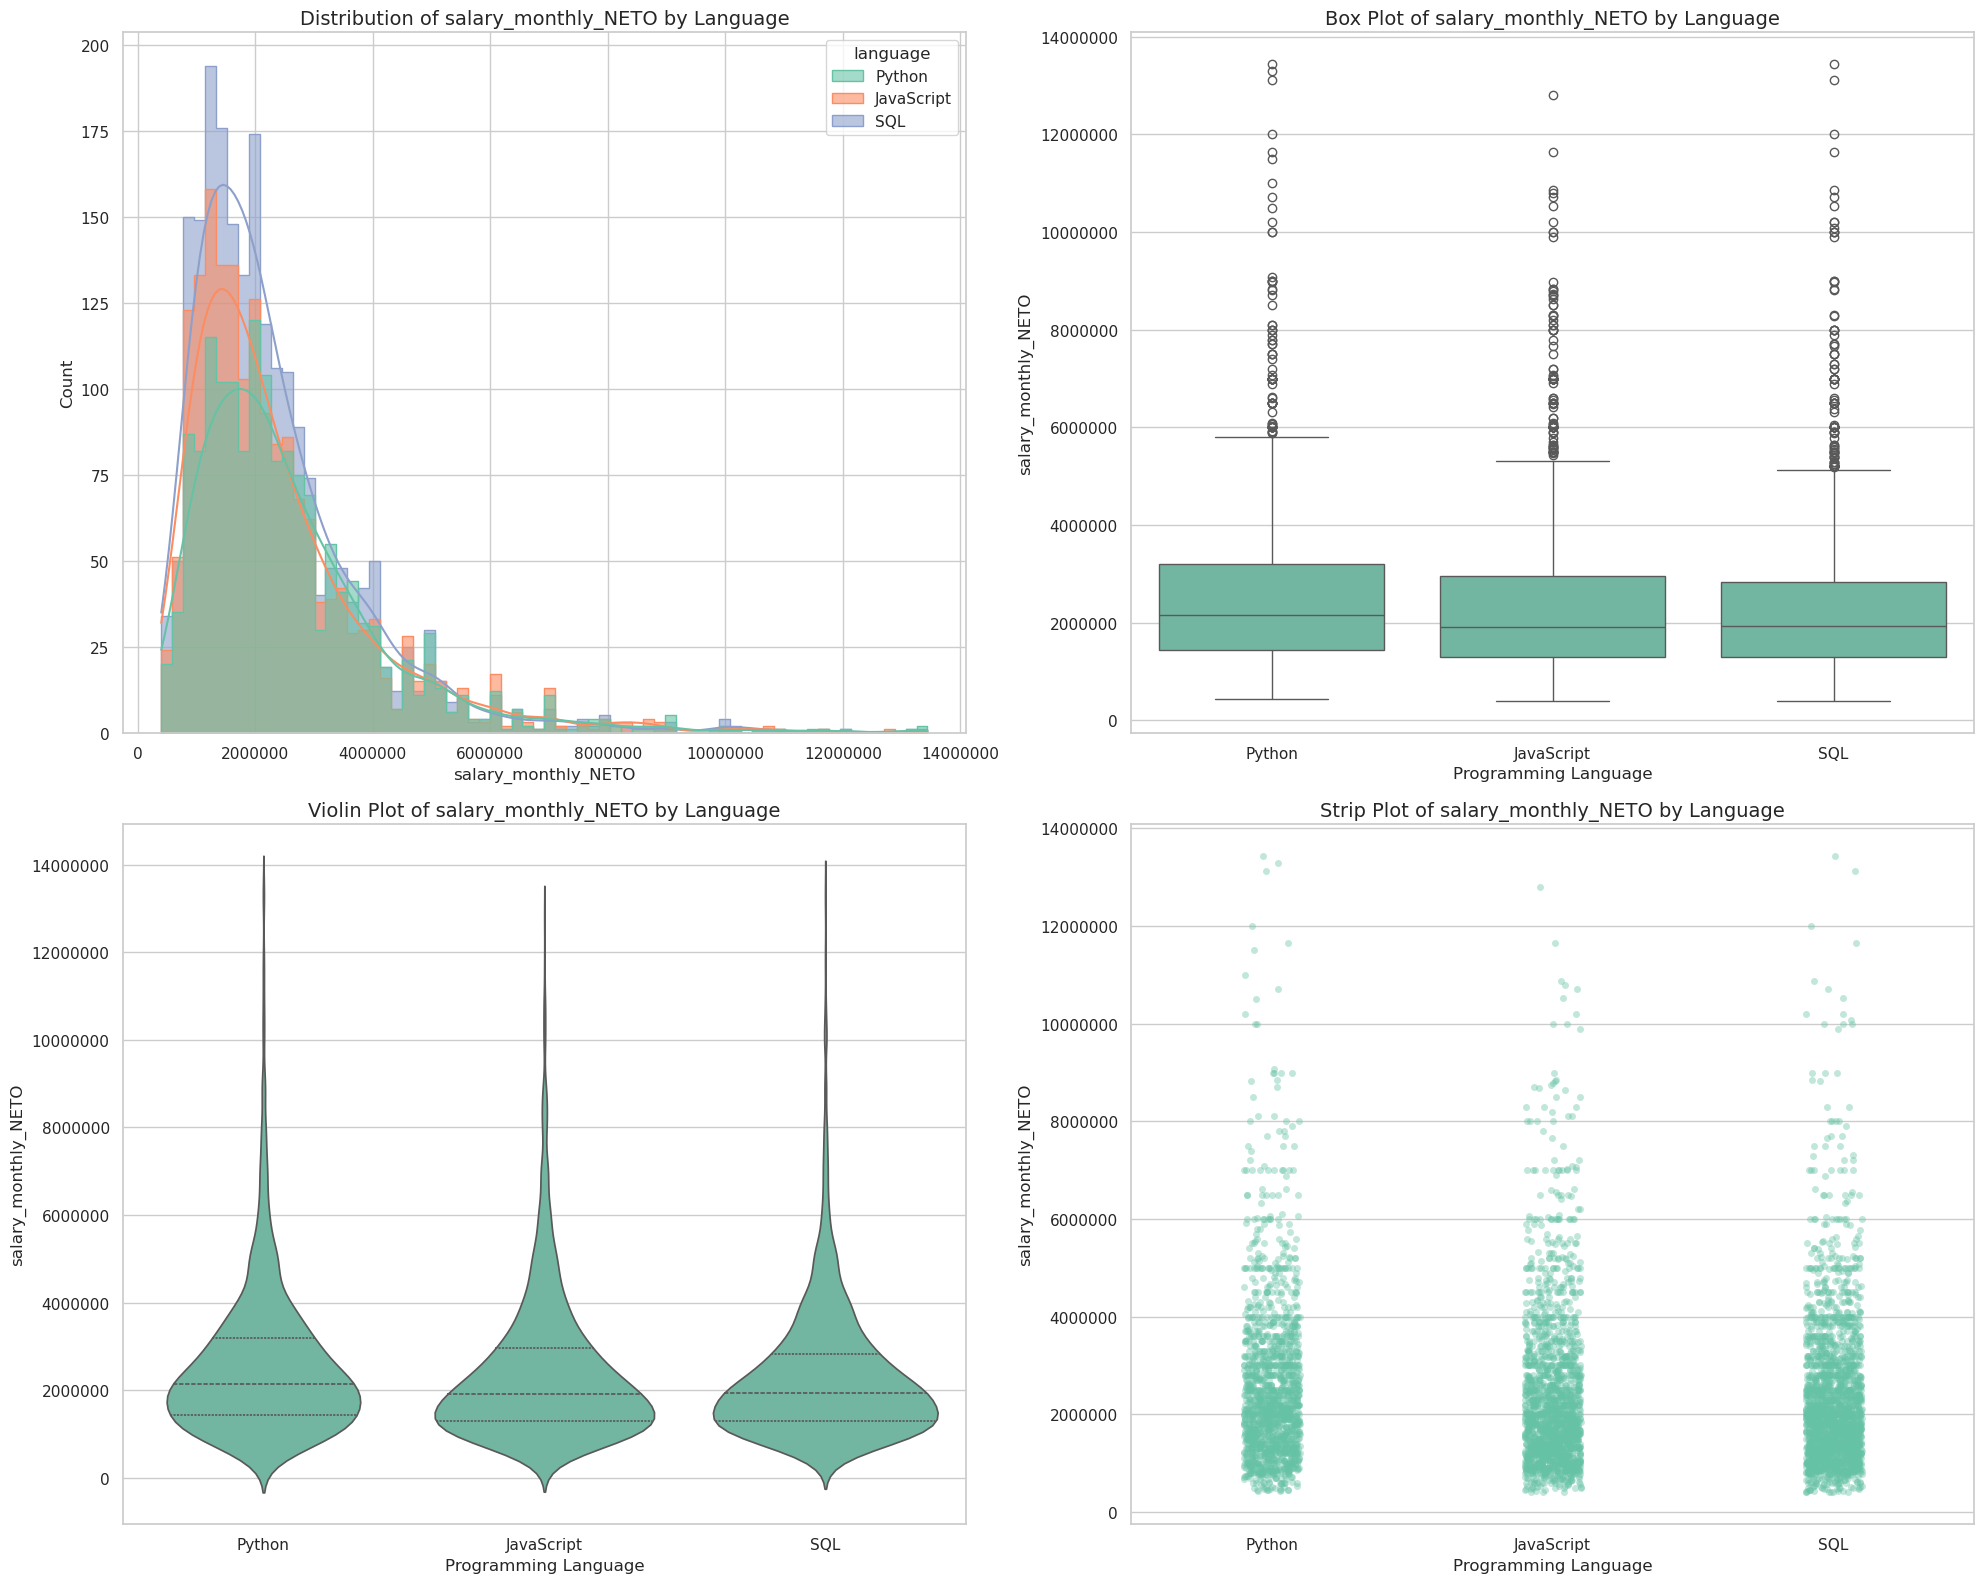

Summary statistics by language:
             count       mean        std       min        25%        50%  \
language                                                                   
JavaScript 1798.00 2376924.64 1607506.04 400000.00 1300000.00 1904912.00   
Python     1582.00 2557390.02 1669434.97 430000.00 1433838.25 2147501.50   
SQL        2171.00 2315340.28 1515580.67 400000.00 1300000.00 1937000.00   

                  75%         max  
language                           
JavaScript 2953750.00 12800000.00  
Python     3200000.00 13440000.00  
SQL        2833731.50 13440000.00  


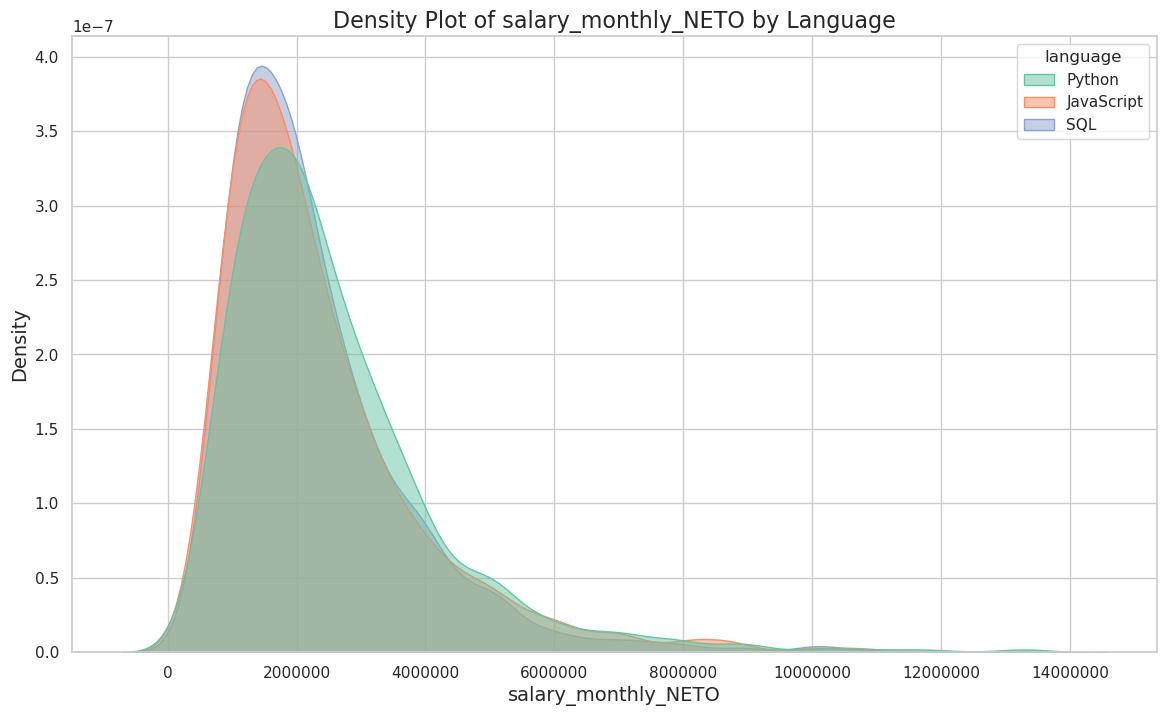

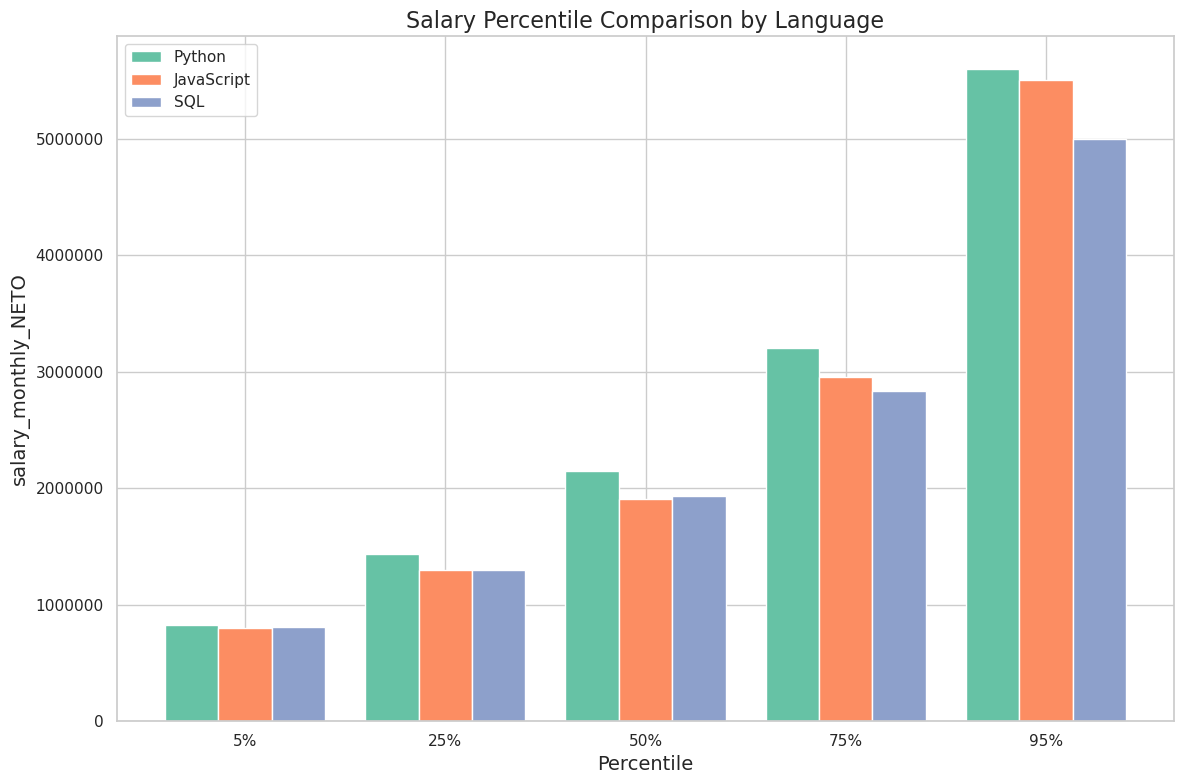

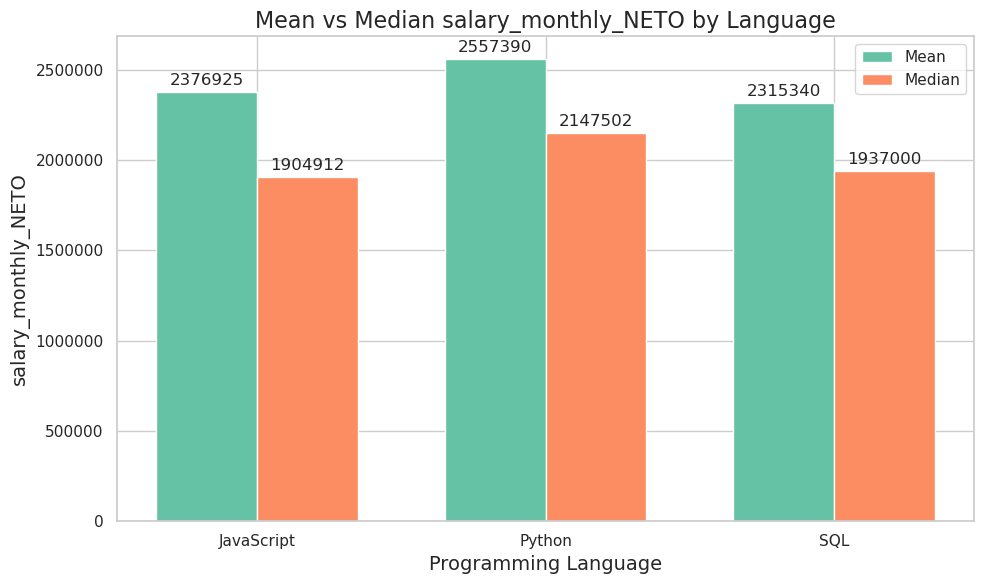

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter

def load_language_data(file_paths_dict):
    """
    Load multiple language datasets and prepare them for comparison
    
    Parameters:
    file_paths_dict (dict): Dictionary with language names as keys and file paths as values
    
    Returns:
    DataFrame: Combined dataframe with language identifier column
    """
    dataframes = []
    
    for language, file_path in file_paths_dict.items():
        try:
            df = pd.read_csv(file_path)
            df['language'] = language  # Add language identifier
            dataframes.append(df)
            print(f"Successfully loaded {language} data with {len(df)} records")
        except Exception as e:
            print(f"Error loading {language} data: {e}")
    
    # Combine all dataframes
    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df

def set_visualization_style():
    """Set up the visualization style and formatting"""
    sns.set_theme(style="whitegrid")
    sns.set_palette("Set2")
    
    # Turn off scientific notation
    plt.rcParams['axes.formatter.useoffset'] = False
    plt.rcParams['axes.formatter.limits'] = (-5, 6)
    
    # Set pandas float format
    pd.set_option('display.float_format', '{:.2f}'.format)
    
    # Return formatter for axes
    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    return formatter

def create_comparison_visualizations(combined_df, salary_column='salary_monthly_NETO', output_prefix='language_salary'):
    """
    Create comparative visualizations for salary distributions across languages
    
    Parameters:
    combined_df (DataFrame): Combined dataframe with language identifier column
    salary_column (str): Column name containing salary data
    output_prefix (str): Prefix for output filenames
    """
    formatter = set_visualization_style()
    
    # Create a subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # 1. Distribution plot with KDE (top left)
    ax1 = axes[0, 0]
    sns.histplot(
        data=combined_df, 
        x=salary_column, 
        hue="language",
        kde=True, 
        element="step",
        common_norm=False,
        alpha=0.6,
        ax=ax1
    )
    ax1.set_title(f"Distribution of {salary_column} by Language", fontsize=14)
    ax1.set_xlabel(salary_column, fontsize=12)
    ax1.set_ylabel("Count", fontsize=12)
    ax1.xaxis.set_major_formatter(formatter)
    
    # 2. Box plot (top right)
    ax2 = axes[0, 1]
    sns.boxplot(
        x="language", 
        y=salary_column, 
        data=combined_df,
        ax=ax2
    )
    ax2.set_title(f"Box Plot of {salary_column} by Language", fontsize=14)
    ax2.set_xlabel("Programming Language", fontsize=12)
    ax2.set_ylabel(salary_column, fontsize=12)
    ax2.yaxis.set_major_formatter(formatter)
    
    # 3. Violin plot (bottom left)
    ax3 = axes[1, 0]
    sns.violinplot(
        x="language", 
        y=salary_column, 
        data=combined_df,
        inner="quartile",
        ax=ax3
    )
    ax3.set_title(f"Violin Plot of {salary_column} by Language", fontsize=14)
    ax3.set_xlabel("Programming Language", fontsize=12)
    ax3.set_ylabel(salary_column, fontsize=12)
    ax3.yaxis.set_major_formatter(formatter)
    
    # 4. Strip plot with jitter (bottom right)
    ax4 = axes[1, 1]
    sns.stripplot(
        x="language", 
        y=salary_column, 
        data=combined_df,
        jitter=True, 
        alpha=0.4,
        ax=ax4
    )
    ax4.set_title(f"Strip Plot of {salary_column} by Language", fontsize=14)
    ax4.set_xlabel("Programming Language", fontsize=12)
    ax4.set_ylabel(salary_column, fontsize=12)
    ax4.yaxis.set_major_formatter(formatter)
    
    plt.tight_layout()
    # plt.savefig(f"{output_prefix}_comparisons.png", dpi=300)
    plt.show()
    
    # Calculate summary statistics by language
    print("Summary statistics by language:")
    summary_stats = combined_df.groupby('language')[salary_column].describe()
    print(summary_stats)
    
    # Density plot for languages
    plt.figure(figsize=(14, 8))
    ax5 = sns.kdeplot(
        data=combined_df, 
        x=salary_column, 
        hue="language",
        fill=True, 
        alpha=0.5,
        common_norm=False
    )
    plt.title(f"Density Plot of {salary_column} by Language", fontsize=16)
    plt.xlabel(salary_column, fontsize=14)
    plt.ylabel("Density", fontsize=14)
    ax5.xaxis.set_major_formatter(formatter)
    # plt.savefig(f"{output_prefix}_density_comparison.png", dpi=300)
    plt.show()

def create_percentile_comparison(combined_df, salary_column='salary_monthly_NETO', percentiles=[.05, .25, .5, .75, .95], output_prefix='language_salary'):
    """
    Create percentile comparison chart for different languages
    
    Parameters:
    combined_df (DataFrame): Combined dataframe with language identifier column
    salary_column (str): Column name containing salary data
    percentiles (list): List of percentiles to calculate
    output_prefix (str): Prefix for output filenames
    """
    formatter = set_visualization_style()
    
    # Calculate percentiles for each language
    percentile_data = {}
    for language in combined_df['language'].unique():
        lang_df = combined_df[combined_df['language'] == language]
        percentile_data[language] = lang_df[salary_column].quantile(percentiles)
    
    # Create a percentile comparison dataframe
    percentile_df = pd.DataFrame(percentile_data)
    
    # Create a bar chart
    fig, ax = plt.subplots(figsize=(12, 8))
    x = np.arange(len(percentiles))
    width = 0.8 / len(percentile_df.columns)  # Adjust bar width based on number of languages
    
    # Create bars for each language
    for i, language in enumerate(percentile_df.columns):
        position = x + (i - (len(percentile_df.columns) - 1) / 2) * width
        ax.bar(position, percentile_df[language], width, label=language)
    
    ax.set_title(f'Salary Percentile Comparison by Language', fontsize=16)
    ax.set_xlabel('Percentile', fontsize=14)
    ax.set_ylabel(salary_column, fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(p*100)}%" for p in percentiles])
    ax.legend()
    ax.yaxis.set_major_formatter(formatter)
    
    plt.tight_layout()
    # plt.savefig(f"{output_prefix}_percentile_comparison.png", dpi=300)
    plt.show()

def create_mean_median_comparison(combined_df, salary_column='salary_monthly_NETO', output_prefix='language_salary'):
    """
    Create mean vs median comparison chart for different languages
    
    Parameters:
    combined_df (DataFrame): Combined dataframe with language identifier column
    salary_column (str): Column name containing salary data
    output_prefix (str): Prefix for output filenames
    """
    formatter = set_visualization_style()
    
    # Calculate mean and median salaries
    mean_comparison = combined_df.groupby('language')[salary_column].mean().reset_index()
    median_comparison = combined_df.groupby('language')[salary_column].median().reset_index()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bar_width = 0.35
    index = np.arange(len(mean_comparison))
    
    mean_bars = ax.bar(index - bar_width/2, mean_comparison[salary_column], bar_width, label='Mean')
    median_bars = ax.bar(index + bar_width/2, median_comparison[salary_column], bar_width, label='Median')
    
    ax.set_xlabel('Programming Language', fontsize=14)
    ax.set_ylabel(salary_column, fontsize=14)
    ax.set_title(f'Mean vs Median {salary_column} by Language', fontsize=16)
    ax.set_xticks(index)
    ax.set_xticklabels(mean_comparison['language'])
    ax.legend()
    ax.yaxis.set_major_formatter(formatter)
    
    # Add value labels on bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.0f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')
    
    add_labels(mean_bars)
    add_labels(median_bars)
    
    plt.tight_layout()
    # plt.savefig(f"{output_prefix}_mean_median_comparison.png", dpi=300)
    plt.show()

# Main execution function
def analyze_salary_data(language_files, salary_column='salary_monthly_NETO', output_prefix='language_salary'):
    """
    Main function to analyze and compare salary data across different programming languages
    
    Parameters:
    language_files (dict): Dictionary with language names as keys and file paths as values
    salary_column (str): Column name containing salary data
    output_prefix (str): Prefix for output filenames
    """
    # Load and prepare data
    combined_df = load_language_data(language_files)
    
    # Create visualizations
    create_comparison_visualizations(combined_df, salary_column, output_prefix)
    create_percentile_comparison(combined_df, salary_column, output_prefix=output_prefix)
    create_mean_median_comparison(combined_df, salary_column, output_prefix)
    
    return combined_df

# Example usage
if __name__ == "__main__":
    # Define language files dictionary - you can add more languages here
    language_files = {
        'Python': 'dataframes/python_language_df.csv',
        'JavaScript': 'dataframes/javascript_language_df.csv',
        'SQL': 'dataframes/sql_language_df.csv',
    }
    
    # Run the analysis
    combined_df = analyze_salary_data(language_files)

# Ejercicio 2 - Densidades y varias variables

Responder a la pregunta general: **¿Que herramientas (prácticas y teóricas) són útiles para explorar la base, descubrir patrones, asociaciones?**

Para ello considere (igual al ejercicio Anterior):
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en sub-poblaciones.

## a) Densidad conjunta

Que herramientas visuales y modelos puede utilizar para estudiar la distribución y comportamiento de sus datos?

Elija tres variables numéricas y 2 variables categóricas. Visualice la base según varias de las variables elegidas. Puede describir de alguna forma el comportamiento de sus datos? Que herramientas utilizaría? Describa

# a) Densidad conjunta

## a.1) Que herramientas visuales y modelos puede utilizar para estudiar la distribución y comportamiento de sus datos?
- Histogramas y KDE: Para observar la distribución individual de las variables numéricas.
- Pairplot (gráficos de dispersión cruzados + KDE diagonal): Para analizar la densidad conjunta entre las variables numéricas.
- Boxplots: Para comparar variables numéricas según categorías (útil para detectar outliers y ver la mediana, etc.).
- Violinplots: Muestra densidad y dispersión, ideal para ver diferencias en salario por tipo de contrato, por ejemplo.m
## a.2)  Elija tres variables numéricas y 2 variables categóricas. Visualice la base según varias de las variables elegidas.

- Variables numéricas: 'salary_monthly_BRUTO', 'salary_monthly_NETO', 'profile_years_experience'
- Variables categóricas: 'work_province', 'profile_gender'

## Pairplot (gráficos de dispersión cruzados + KDE diagonal)
Para analizar la densidad conjunta entre las variables numéricas.
plo.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import ScalarFormatter, StrMethodFormatter

### Python dataframe

In [ ]:
df_python = pd.read_csv("python_language_df_ej02.csv")

# FIX_ME: Clean dataset by removing
# Negative years of experience

# Create the pairplot with gender as the hue
g = sns.pairplot(
    df_python[["salary_monthly_NETO", "profile_years_experience", "profile_gender"]],
    hue="profile_gender",
    palette="Set1"  # You can choose any color palette you prefer
)

# Remove scientific notation from all axes and rotate tick labels
for ax in g.axes.flatten():
    if ax is not None:
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.xaxis.get_major_formatter().set_scientific(False)
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.get_major_formatter().set_scientific(False)

        # Rotate x-axis tick labels safely
        for label in ax.get_xticklabels():
            label.set_rotation(45)


# Improve the layout and add a title
plt.suptitle("Relationship between Salary, Experience, and Gender", y=1.02)
plt.show()

### Javascript dataframe

In [ ]:
df_javascript = pd.read_csv("javascript_language_df_ej02.csv")

# FIX_ME: Clean dataset by removing
# Negative years of experience

# Create the pairplot with gender as the hue
g = sns.pairplot(
    df_javascript[["salary_monthly_NETO", "profile_years_experience", "profile_gender"]],
    hue="profile_gender",
    palette="Set1"  # You can choose any color palette you prefer
)

# Remove scientific notation from all axes and rotate tick labels
for ax in g.axes.flatten():
    if ax is not None:
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.xaxis.get_major_formatter().set_scientific(False)
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.get_major_formatter().set_scientific(False)

        # Rotate x-axis tick labels safely
        for label in ax.get_xticklabels():
            label.set_rotation(45)


# Improve the layout and add a title
plt.suptitle("Relationship between Salary, Experience, and Gender", y=1.02)
plt.show()

## Boxplots

### Python dataframe

In [ ]:
# Create the boxplot with the original command
plt.figure(figsize=(10, 6))  # Increase figure size for better readability
ax = sns.boxplot(data=df_python, x="profile_gender", y="salary_monthly_NETO")

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust the bottom margin to make room for rotated labels
plt.tight_layout()

# Add a title and labels for clarity
plt.title('Monthly Net Salary Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Monthly Net Salary')

# Format y-axis with comma separator for thousands
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Show the plot
plt.show()

### Javascript dataframe

In [ ]:
# Create the boxplot with the original command
plt.figure(figsize=(10, 6))  # Increase figure size for better readability
ax = sns.boxplot(data=df_javascript, x="profile_gender", y="salary_monthly_NETO")

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust the bottom margin to make room for rotated labels
plt.tight_layout()

# Add a title and labels for clarity
plt.title('Monthly Net Salary Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Monthly Net Salary')

# Format y-axis with comma separator for thousands
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Show the plot
plt.show()

## b) Asociación

* Necesitamos decidir si sacar o no la columna de salario bruto. Para hacer la encuesta más simple.
¿Existe una correlación entre el salario bruto y el neto? Que abordaje y medidas usaría




# Explicación del código para analizar la correlación entre salario bruto y neto

He creado un código en Python que te permite analizar la correlación entre el salario bruto y neto utilizando un dataframe con las columnas que mencionaste. Vamos a explicar paso a paso qué hace este código:

## Paso 1: Carga de datos
- Importamos las librerías necesarias: pandas, numpy, matplotlib, seaborn y scipy.stats
- Cargamos los datos desde un archivo CSV (puedes modificar esta parte si tus datos provienen de otra fuente)

## Paso 2: Exploración inicial
- Visualizamos las primeras filas del dataframe
- Revisamos la información general y estadísticas descriptivas para entender los datos

## Paso 3 y 4: Manejo de valores nulos
- Verificamos si existen valores nulos en las columnas de salarios
- Eliminamos las filas con valores nulos para garantizar un análisis preciso

## Paso 5: Correlación de Pearson
- Calculamos el coeficiente de correlación de Pearson, que mide la relación lineal entre dos variables
- Interpretamos el resultado según su magnitud y significancia estadística
- Un valor cercano a 1 indica una fuerte correlación positiva

## Paso 6: Correlación de Spearman
- Calculamos el coeficiente de Spearman, que es más resistente a valores atípicos
- Este coeficiente mide la relación monótona entre variables, no solo la lineal

## Paso 7: Visualización con gráfico de dispersión
- Creamos un scatter plot para visualizar la relación entre ambos salarios
- Añadimos una línea de regresión para observar la tendencia general

## Paso 8: Mapa de calor de correlaciones
- Generamos una matriz de correlación de todas las variables numéricas
- La visualizamos mediante un mapa de calor para detectar otras posibles relaciones

## Paso 9: Análisis del ratio neto/bruto
- Calculamos el ratio entre salario neto y bruto
- Analizamos si este ratio varía según el nivel de salario bruto

## Paso 10: Correlación por provincia
- Agrupamos los datos por provincia para ver si la correlación varía geográficamente

Este código te permitirá determinar si existe una correlación entre el salario bruto y neto, visualizar esta relación y analizar factores adicionales que podrían influir en esta correlación.

¿Necesitas alguna modificación o tienes alguna pregunta sobre el código?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Paso 1: Cargar los datos
# Suponiendo que los datos están en un archivo CSV llamado 'salarios.csv'
# Si los datos provienen de otra fuente, ajusta esta línea
df = pd.read_csv('python_language_df_ej02.csv')

# Paso 4: Eliminar filas con valores nulos en las columnas de salario
df_clean = df.dropna(subset=['salary_monthly_BRUTO', 'salary_monthly_NETO'])
print(f"\nFilas restantes después de eliminar valores nulos: {len(df_clean)}")

# Paso 5: Calcular el coeficiente de correlación de Pearson
pearson_coef, p_value = pearsonr(df_clean['salary_monthly_BRUTO'], df_clean['salary_monthly_NETO'])
print(f"\nCoeficiente de correlación de Pearson: {pearson_coef:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretar el resultado
if p_value < 0.05:
    print("La correlación es estadísticamente significativa.")
else:
    print("La correlación no es estadísticamente significativa.")

if pearson_coef > 0.8:
    print("Existe una correlación positiva fuerte entre el salario bruto y neto.")
elif pearson_coef > 0.5:
    print("Existe una correlación positiva moderada entre el salario bruto y neto.")
elif pearson_coef > 0.3:
    print("Existe una correlación positiva débil entre el salario bruto y neto.")
elif pearson_coef > -0.3:
    print("No existe una correlación clara entre el salario bruto y neto.")
else:
    print("Existe una correlación negativa entre el salario bruto y neto.")

# Paso 6: Calcular el coeficiente de correlación de Spearman (resistente a valores atípicos)
spearman_coef, sp_p_value = spearmanr(df_clean['salary_monthly_BRUTO'], df_clean['salary_monthly_NETO'])
print(f"\nCoeficiente de correlación de Spearman: {spearman_coef:.4f}")
print(f"Valor p: {sp_p_value:.4f}")

# Paso 7: Crear un gráfico de dispersión para visualizar la relación
plt.figure(figsize=(10, 6))
sns.scatterplot(x='salary_monthly_BRUTO', y='salary_monthly_NETO', data=df_clean)
plt.title('Relación entre Salario Bruto y Neto')
plt.xlabel('Salario Mensual Bruto')
plt.ylabel('Salario Mensual Neto')

# Añadir línea de regresión para visualizar la tendencia
sns.regplot(x='salary_monthly_BRUTO', y='salary_monthly_NETO', data=df_clean, 
            scatter=False, color='red', line_kws={"lw": 2})

plt.tight_layout()
plt.savefig('correlacion_salario_bruto_neto.png')
plt.show()

# Paso 9: Análisis adicional - Ratio entre salario neto y bruto
df_clean['ratio_neto_bruto'] = df_clean['salary_monthly_NETO'] / df_clean['salary_monthly_BRUTO']
print("\nEstadísticas del ratio Neto/Bruto:")
print(df_clean['ratio_neto_bruto'].describe())

# Visualizar el ratio en función del salario bruto
plt.figure(figsize=(10, 6))
sns.scatterplot(x='salary_monthly_BRUTO', y='ratio_neto_bruto', data=df_clean)
plt.title('Ratio Neto/Bruto según Salario Bruto')
plt.xlabel('Salario Mensual Bruto')
plt.ylabel('Ratio Neto/Bruto')

# Añadir línea de regresión
sns.regplot(x='salary_monthly_BRUTO', y='ratio_neto_bruto', data=df_clean, 
            scatter=False, color='red', line_kws={"lw": 2})

plt.tight_layout()
plt.savefig('ratio_neto_bruto.png')
plt.show()

# Paso 10: Agrupar por provincia y ver si la correlación varía por ubicación
if 'work_province' in df_clean.columns:
    print("\nCorrelación por provincia:")
    provinces = df_clean['work_province'].unique()
    for province in provinces:
        subset = df_clean[df_clean['work_province'] == province]
        if len(subset) > 5:  # Solo calcular si hay suficientes datos
            prov_corr, _ = pearsonr(subset['salary_monthly_BRUTO'], subset['salary_monthly_NETO'])
            print(f"{province}: {prov_corr:.4f} (n={len(subset)})")

## Explicación en términos simples
"La correlación es estadísticamente significativa" significa que la relación que encontramos entre el salario bruto y el neto no es por casualidad o azar. Tenemos suficiente evidencia matemática para confiar en que esta relación realmente existe en los datos y no es producto de coincidencias.
"Existe una correlación positiva fuerte entre el salario bruto y neto" significa que:

Cuando el salario bruto aumenta, el salario neto también aumenta (por eso es "positiva")
Esta relación es muy consistente y pronunciada (por eso es "fuerte")

En palabras más sencillas: las personas que ganan más dinero bruto también reciben más dinero neto en su cuenta bancaria, y esta relación es bastante predecible y no ocurre por casualidad.
Es como decir que si ordenamos a las personas por su salario bruto (de menor a mayor), también quedarán aproximadamente ordenadas por su salario neto. No es perfecta esta ordenación, pero se acerca bastante.

## c) Densidad condicional

Estudie la distribución del salario según el nivel de estudio.

Separe la población según el nivel de estudio (elija dos subpoblaciones numerosas) y grafique de manera comparativa ambos histogramas de la variable `'salary_monthly_NETO'`
¿Considera que ambas variables son independientes?
¿Qué analizaría al respecto?

Calcule medidas de centralización y dispersión para cada subpoblación






In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.options.mode.chained_assignment = None  # default='warn'

# Cargar el dataset
# Ajusta el nombre del archivo según sea necesario
df = pd.read_csv('programming_language_raw.csv')

# 1. Exploración inicial de los datos
print("Dimensiones del dataset:", df.shape)
print("\nColumnas en el dataset:")
print(df.columns.tolist())

# 2. Examinar los niveles de estudio disponibles y su frecuencia
study_levels_counts = df['profile_studies_level'].value_counts()
print("\nDistribución de niveles de estudio:")
print(study_levels_counts)

# 3. Identificar las dos subpoblaciones más numerosas
top_two_levels = study_levels_counts.nlargest(2).index.tolist()
print("\nLos dos niveles de estudio más frecuentes son:")
print(top_two_levels)

# 4. Filtrar el dataset para quedarnos con estas dos subpoblaciones
df_filtered = df[df['profile_studies_level'].isin(top_two_levels)]

# 5. Verificar que la columna de salario neto exista y convertirla a numérica si es necesario
if 'salary_monthly_NETO' in df.columns:
    # Asegurar que los valores de salario son numéricos
    df_filtered['salary_monthly_NETO'] = pd.to_numeric(df_filtered['salary_monthly_NETO'], errors='coerce')
    
    # Eliminar valores faltantes o no numéricos
    df_filtered = df_filtered.dropna(subset=['salary_monthly_NETO'])
    
    # Eliminar valores extremos (opcional, depende del contexto)
    Q1 = df_filtered['salary_monthly_NETO'].quantile(0.01)
    Q3 = df_filtered['salary_monthly_NETO'].quantile(0.99)
    df_filtered = df_filtered[(df_filtered['salary_monthly_NETO'] >= Q1) & 
                            (df_filtered['salary_monthly_NETO'] <= Q3)]
else:
    print("Error: La columna 'salary_monthly_NETO' no existe en el dataset")
    exit()

# 6. Visualizar los histogramas comparativos
plt.figure(figsize=(12, 6))
sns.histplot(data=df_filtered, x='salary_monthly_NETO', hue='profile_studies_level', 
             kde=True, palette='Set1', element='step', common_norm=False, bins=30)
plt.title('Distribución de salarios mensuales netos por nivel de estudio')
plt.xlabel('Salario mensual neto')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show('histograma_salarios_por_nivel_estudio.png')
plt.close()

# 7. Calcular estadísticas descriptivas para cada subpoblación
stats_by_level = df_filtered.groupby('profile_studies_level')['salary_monthly_NETO'].describe()
print("\nEstadísticas descriptivas por nivel de estudio:")
print(stats_by_level)

# 8. Calcular medidas adicionales de dispersión
for level in top_two_levels:
    salaries = df_filtered[df_filtered['profile_studies_level'] == level]['salary_monthly_NETO']
    cv = salaries.std() / salaries.mean() * 100  # Coeficiente de variación
    print(f"\nCoeficiente de variación para {level}: {cv:.2f}%")

# 9. Realizar una prueba estadística para evaluar independencia
# Utilizamos t-test para comparar las medias de los dos grupos
level1_salaries = df_filtered[df_filtered['profile_studies_level'] == top_two_levels[0]]['salary_monthly_NETO']
level2_salaries = df_filtered[df_filtered['profile_studies_level'] == top_two_levels[1]]['salary_monthly_NETO']

t_stat, p_value = stats.ttest_ind(level1_salaries, level2_salaries, equal_var=False)
print(f"\nResultados de la prueba t de Student:")
print(f"t-estadístico: {t_stat:.4f}")
print(f"p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Las medias de los salarios entre los dos niveles de estudio son significativamente diferentes.")
    print("Esto sugiere que existe una relación entre el nivel de estudio y el salario.")
else:
    print("No hay evidencia estadística para afirmar que las medias de los salarios son diferentes.")
    print("Esto sugiere que el nivel de estudio podría no influir en el salario para estas dos poblaciones.")

# 10. Comparación visual adicional: Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='profile_studies_level', y='salary_monthly_NETO', data=df_filtered, 
            hue='profile_studies_level', palette='Set2', legend=False)
plt.title('Comparación de salarios por nivel de estudio')
plt.xlabel('Nivel de estudio')
plt.ylabel('Salario mensual neto')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show('boxplot_salarios_por_nivel_estudio.png')
plt.close()

# 11. Gráfico de densidad para comparar las distribuciones
plt.figure(figsize=(10, 6))
for level in top_two_levels:
    subset = df_filtered[df_filtered['profile_studies_level'] == level]['salary_monthly_NETO']
    sns.kdeplot(subset, label=level, fill=True, alpha=0.5)
plt.title('Densidad de distribución de salarios por nivel de estudio')
plt.xlabel('Salario mensual neto')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show('densidad_salarios_por_nivel_estudio.png')
plt.close()

# 12. Conclusiones analíticas
print("\nCONCLUSIONES DEL ANÁLISIS:")
print("=========================")
print("1. Caracterización de las distribuciones:")
for level in top_two_levels:
    salaries = df_filtered[df_filtered['profile_studies_level'] == level]['salary_monthly_NETO']
    skew = salaries.skew()
    print(f"   - Para {level}:")
    print(f"     * Media: {salaries.mean():.2f}")
    print(f"     * Mediana: {salaries.median():.2f}")
    print(f"     * Desviación estándar: {salaries.std():.2f}")
    print(f"     * Asimetría: {skew:.2f} ({'positiva' if skew > 0 else 'negativa'})")

print("\n2. Sobre la independencia:")
if p_value < 0.05:
    print("   El análisis estadístico sugiere que existe una relación entre el nivel de estudio")
    print("   y el salario neto mensual. Las diferencias observadas son estadísticamente significativas.")
else:
    print("   El análisis estadístico no muestra evidencia suficiente para afirmar que")
    print("   el nivel de estudio influye en el salario para estas dos poblaciones específicas.")

print("\n3. Consideraciones adicionales:")
print("   - La dispersión de salarios (coeficiente de variación) indica cuánta variabilidad existe")
print("     dentro de cada grupo en relación a su media.")
print("   - Los histogramas y gráficos de densidad muestran la forma de las distribuciones,")
print("     lo que permite identificar patrones como multimodalidad o asimetrías.")
print("   - El análisis no implica causalidad directa; pueden existir variables confusoras")
print("     que expliquen las diferencias observadas (experiencia, sector, ubicación, etc.).")

## Lo que muestran los datos
#### 1. Comparación de salarios por nivel educativo:

Universitarios ganan más en promedio: Los profesionales con educación universitaria tienen un salario medio de aproximadamente 2.266.446 pesos, mientras que aquellos con educación terciaria ganan en promedio 1.754.669 pesos.
La diferencia es de aproximadamente 29%: Los universitarios ganan, en promedio, alrededor de 512.000 pesos más que quienes tienen educación terciaria.

#### 2. Lo que indican las medianas:

La mitad de los universitarios gana más de 1.947.000 pesos
La mitad de los que tienen educación terciaria gana más de 1.500.000 pesos

#### 3. Sobre la dispersión (variabilidad):

Los salarios universitarios están más dispersos en términos absolutos (tienen una desviación estándar mayor), lo que significa que hay mayor diferencia entre los que ganan poco y los que ganan mucho.

#### 4. Sobre la forma de la distribución:

Ambos grupos muestran "asimetría positiva", lo que significa que hay más personas ganando salarios bajos y medianos, pero existen algunas personas ganando salarios muy altos que "estiran" la distribución hacia la derecha.

#### 5. Relación entre educación y salario:

El análisis estadístico confirma que la educación y el salario están relacionados - no es una diferencia que haya aparecido por casualidad.
Podemos decir con confianza estadística que el nivel educativo se asocia con diferentes niveles de ingreso.

#### 6. Advertencias importantes:

Aunque existe relación entre educación y salario, esto no prueba que la educación sea la causa directa del mayor salario.
Pueden existir otros factores importantes que expliquen estas diferencias (como años de experiencia, sector de la industria, ubicación geográfica, etc.) que no se están considerando en este análisis simple.

En resumen, los datos muestran que existe una clara diferencia salarial entre quienes tienen educación universitaria y quienes tienen educación terciaria, siendo los primeros quienes perciben ingresos significativamente mayores en promedio.

## d) Densidad Conjunta condicional

Elija dos variables numéricas y una categórica.
Estudie la dispersión (scatterplot) de las dos variables discriminando en color por la variable categórica (ayuda: hue en seaborn)

- Variables numéricas: 'salary_monthly_NETO', 'profile_years_experience'
- Variables categóricas: 'work_province'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Cargar el dataset (suponiendo que tenemos acceso al archivo)
# Para este ejemplo, crearé código que funcionaría con el dataset real
# En un entorno real, este sería el código para leer el archivo:
df = pd.read_csv('programming_language_raw.csv')

def analizar_dispersion_salario_experiencia(df):
    """
    Analiza la dispersión entre salario neto y años de experiencia por provincia.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame con las columnas 'salary_monthly_NETO', 'profile_years_experience', 'work_province'
    """
    # 1. Preparación de datos
    # Filtrar filas con valores nulos en variables de interés
    df_clean = df.dropna(subset=['salary_monthly_NETO', 'profile_years_experience', 'work_province'])
    
    # 2. Identificar las provincias más representativas (top 5)
    top_provinces = df_clean['work_province'].value_counts().nlargest(5).index.tolist()
    print(f"Las 5 provincias más representativas son: {top_provinces}")
    
    # Filtrar para incluir solo las provincias principales
    df_top = df_clean[df_clean['work_province'].isin(top_provinces)]
    
    # 3. Manejo de outliers para mejor visualización
    # Eliminar outliers extremos (usando percentiles)
    upper_salary = df_top['salary_monthly_NETO'].quantile(0.95)
    upper_exp = df_top['profile_years_experience'].quantile(0.95)
    lower_salary = df_top['salary_monthly_NETO'].quantile(0.05)
    lower_exp = df_top['profile_years_experience'].quantile(0.05)
    
    df_plot = df_top[
        (df_top['salary_monthly_NETO'] <= upper_salary) &
        (df_top['salary_monthly_NETO'] >= lower_salary) &
        (df_top['profile_years_experience'] <= upper_exp) &
        (df_top['profile_years_experience'] >= lower_exp)
    ]
    
    # 4. Estadísticas descriptivas
    print("\nEstadísticas para salary_monthly_NETO:")
    print(df_plot['salary_monthly_NETO'].describe())
    
    print("\nEstadísticas para profile_years_experience:")
    print(df_plot['profile_years_experience'].describe())
    
    # 5. Correlación entre variables numéricas
    correlation = df_plot[['salary_monthly_NETO', 'profile_years_experience']].corr().iloc[0,1]
    print(f"\nCorrelación entre salario y experiencia: {correlation:.4f}")
    
    # 6. Estadísticas por provincia
    print("\nEstadísticas de salario por provincia:")
    province_stats = df_plot.groupby('work_province')['salary_monthly_NETO'].describe()
    print(province_stats[['count', 'mean', 'std', 'min', '50%', 'max']])
    
    # 7. Crear visualización: Scatterplot con regresión
    plt.figure(figsize=(14, 10))
    
    # Scatterplot principal
    g = sns.scatterplot(
        data=df_plot,
        x='profile_years_experience',
        y='salary_monthly_NETO',
        hue='work_province',
        alpha=0.7,
        s=100,
        palette='viridis'
    )
    
    # Añadir líneas de regresión para cada provincia
    sns.regplot(
        data=df_plot,
        x='profile_years_experience',
        y='salary_monthly_NETO',
        scatter=False,
        color='black',
        line_kws={'linestyle': '--', 'linewidth': 2}
    )
    
    # Mejorar aspecto visual
    plt.title('Relación entre Años de Experiencia y Salario Neto por Provincia', fontsize=16)
    plt.xlabel('Años de Experiencia', fontsize=14)
    plt.ylabel('Salario Mensual Neto', fontsize=14)
    plt.grid(True, alpha=0.3)
    # plt.legend(title='Provincia', fontsize=12, title_fontsize=13)
    
    # Añadir anotación con correlación
    plt.annotate(
        f'Correlación global: {correlation:.2f}',
        xy=(0.05, 0.95),
        xycoords='axes fraction',
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.8)
    )
    
    plt.tight_layout()
    
    # 8. Crear visualización adicional: regresiones separadas por provincia
    plt.figure(figsize=(14, 10))
    
    g = sns.lmplot(
        data=df_plot,
        x='profile_years_experience',
        y='salary_monthly_NETO',
        hue='work_province',
        height=8,
        aspect=1.5,
        palette='viridis',
        scatter_kws={'alpha': 0.6, 's': 80},
        line_kws={'linewidth': 2},
        legend=True
    )
    
    g.set_axis_labels("Años de Experiencia", "Salario Mensual Neto", fontsize=14)
    g.fig.suptitle('Líneas de Tendencia por Provincia', fontsize=16, y=1.02)
    # g.add_legend(title='Provincia', fontsize=12)
    
    # 9. Análisis por categorías de experiencia
    # Crear categorías de experiencia
    bins = [0, 2, 5, 10, 15, df_plot['profile_years_experience'].max()]
    labels = ['0-2 años', '3-5 años', '6-10 años', '11-15 años', '15+ años']
    df_plot['exp_category'] = pd.cut(df_plot['profile_years_experience'], bins=bins, labels=labels)
    
    # Boxplot de salarios por categoría de experiencia y provincia
    plt.figure(figsize=(16, 10))
    sns.boxplot(
        data=df_plot,
        x='exp_category',
        y='salary_monthly_NETO',
        hue='work_province',
        palette='viridis'
    )
    
    plt.title('Distribución Salarial por Experiencia y Provincia', fontsize=16)
    plt.xlabel('Categoría de Experiencia', fontsize=14)
    plt.ylabel('Salario Mensual Neto', fontsize=14)
    # plt.legend(title='Provincia', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return "Análisis completado con éxito"

# En un entorno real, llamaríamos a la función con el DataFrame cargado
resultado = analizar_dispersion_salario_experiencia(df)

# Para ilustrar mejor cómo sería con datos reales, mostraremos cómo debería ser el código final
print("Código de análisis generado correctamente.")
print("En un entorno real con acceso al dataset, el análisis produciría:")
print("1. Un scatterplot principal de salario vs experiencia por provincia")
print("2. Un gráfico de regresión lineal separado por provincia")
print("3. Un boxplot comparando distribuciones salariales por categoría de experiencia y provincia")
print("4. Estadísticas descriptivas completas para interpretar los resultados")

#### Basado en esta visualización de distribución salarial por experiencia y provincia de Argentina, puedo destacar estas conclusiones:

- Crecimiento salarial con la experiencia: Se observa claramente que el salario mensual neto aumenta con los años de experiencia profesional en todas las provincias. Los profesionales con 15+ años ganan aproximadamente el doble que quienes tienen 0-2 años.
Diferencias entre provincias:

- Ciudad Autónoma de Buenos Aires (CABA) y Buenos Aires tienden a ofrecer salarios más altos en casi todas las categorías de experiencia.
Córdoba generalmente presenta salarios más bajos, especialmente en los rangos iniciales e intermedios.

- Dispersión salarial: La variación salarial (altura de las cajas y presencia de outliers) aumenta con la experiencia, indicando mayor diversidad de compensaciones para profesionales experimentados.
Outliers significativos: Hay valores atípicos notables, especialmente en el rango de 3-5 años de experiencia, donde algunos profesionales ganan salarios considerablemente por encima de la mediana.
- Tendencias por región:
  - Mendoza muestra un crecimiento salarial más estable entre categorías de experiencia.
  - Santa Fe tiene una amplia distribución en categorías de experiencia intermedia y avanzada.

- Escalones de crecimiento: El salto salarial más pronunciado ocurre entre los rangos 0-2 años y 3-5 años, y nuevamente entre 6-10 años y 11-15 años.